In [50]:
!apt-get update
!apt-get install -y libglu1-mesa
%pip install numpy matplotlib meshio pygmsh pyvista anywidget
%pip install --upgrade meshio

'apt-get' �́A�����R�}���h�܂��͊O���R�}���h�A
����\�ȃv���O�����܂��̓o�b�` �t�@�C���Ƃ��ĔF������Ă��܂���B
'apt-get' �́A�����R�}���h�܂��͊O���R�}���h�A
����\�ȃv���O�����܂��̓o�b�` �t�@�C���Ƃ��ĔF������Ă��܂���B


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: c:\work\HP4\deepxde\.venv\Scripts\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: c:\work\HP4\deepxde\.venv\Scripts\python.exe -m pip install --upgrade pip


LLMへの指示
ルールの指定
作成したい形状

In [51]:
rules_content = """# pygmsh.occ Geometry Generation Rules (Strict)

You are a CAD/CAE expert. Output ONLY valid Python code using the `pygmsh.occ` API.
The variable `geom` is already initialized.

### 1. Mandatory API Signatures:
- Rectangle: `rect = geom.add_rectangle([x0, y0, z0], width, height)`
- Disk (Circle): `disk = geom.add_disk([xc, yc, zc], radius)`
- Boolean Union: `union = geom.boolean_union([entity1, entity2, ...])`
- Boolean Difference: `diff = geom.boolean_difference(target_entity, tool_entity)`

### 2. Code Structure & Formatting (ULTRA STRICT):
- **Comment Every Line**: Every single line of code MUST include a descriptive comment starting with '#' on the same line.
- **Strict Single-Statement Lines**: Each line MUST contain exactly one statement (assignment or function call). Combining statements is strictly forbidden.
- **NO Multi-variable Assignments**: You MUST NOT define multiple variables on one line (e.g., NO `W, H = 500.0, 200.0`). Define each variable on its own separate line.
- **Mandatory Physical Spacing**: You MUST insert at least one blank line (empty line) between every single valid line of code to ensure physical separation.
- **NO Semicolons**: Semicolons (;) are strictly forbidden for separating or ending statements.
- **Float Only**: Use float values for all dimensions (e.g., 50.0).

### 3. Output Format:
- **No Markdown**: Do NOT use code blocks (```). Start directly with Python code.
- **No Explanation**: Output ONLY the code and comments. No conversational text or preamble.
- **Final Variable**: Assign the final resulting shape to a variable named `final_shape`.

### 4. Physical Groups:
- **Surface**: Always apply `geom.add_physical(final_shape, "SURFACE")`.
- **Boundaries**: To define a boundary (e.g., "left edge"), create a very thin rectangle (0.1 thickness) and label it (e.g., "FIXED_SUPPORT").

### 5. Mesh Stability:
- Avoid overlapping edges to prevent kernel errors.
- Ensure all holes and cutouts are completely contained within the base plate boundaries.

### 6. Correct Style Example (Follow this exactly):
W = 800.0  # Define width

H = 300.0  # Define height

plate = geom.add_rectangle([0.0, 0.0, 0.0], W, H)  # Create base plate

geom.add_physical(plate, "SURFACE")  # Assign surface group
"""

# ファイルとして保存
with open("pygmsh_rules.txt", "w", encoding="utf-8") as f:
    f.write(rules_content)

print("✅ 'pygmsh_rules.txt' has been created successfully.")

✅ 'pygmsh_rules.txt' has been created successfully.


以下メッシュ作成

In [52]:
import pygmsh
import numpy as np
import matplotlib.pyplot as plt
import json

# 設定
OUTPUT_FILE = 'input.json'

print("✅ Libraries loaded.")

✅ Libraries loaded.


LLMのプロンプトからメッシュ生成

In [53]:
def generate_mesh_from_llm(recipe_code, mesh_size=10.0):

    try:
        with pygmsh.occ.Geometry() as geom:
            # メッシュサイズのグローバル設定
            geom.characteristic_length_min = mesh_size
            geom.characteristic_length_max = mesh_size

            # LLMが生成したコードを実行
            # 第2引数に、exec内で使用可能にする変数を辞書で渡します
            exec_globals = {"geom": geom}
            exec(recipe_code, exec_globals)

            # メッシュ生成
            mesh = geom.generate_mesh()
            return mesh

    except Exception as e:
        print(f"❌ Error during mesh generation: {e}")
        return None

User Prompt: 添付した pygmsh_rules.txt のルールを厳守して、以下の形状を作成するPythonコードを出力してください。

要望： 縦300、横800の板の左端を固定したい。中央に三角形のような配置で3つの小さな穴（半径10）を開け、さらに右端の上下の角に小さな切り欠きを作って。

In [59]:
LLM_GEOMETRY_RECIPE = """

W = 700.0 # 板の横幅を定義

H = 350.0 # 板の縦幅を定義

D = 10.0 # 板の厚み（Z方向）を定義

R = 12.0 # 円孔の半径を定義

XC = 350.0 # 円孔のX中心座標

YC_UP = 225.0 # 上側の円孔Y座標

YC_DOWN = 125.0 # 下側の円孔Y座標

NW = 50.0 # 切り欠きの幅

NH = 30.0 # 切り欠きの高さ

NX = 650.0 # 切り欠きの開始X座標

NY = 160.0 # 切り欠きの開始Y座標

rect = geom.add_rectangle([0.0, 0.0, 0.0], W, H) # ベースの2D長方形を作成

hole1 = geom.add_disk([XC, YC_UP, 0.0], R) # 上側の2D円孔を作成

hole2 = geom.add_disk([XC, YC_DOWN, 0.0], R) # 下側の2D円孔を作成

notch = geom.add_rectangle([NX, NY, 0.0], NW, NH) # 切り欠きの2D長方形を作成

holes = geom.boolean_union([hole1, hole2]) # 円孔を結合

temp_2d = geom.boolean_difference(rect, holes) # 長方形から円孔を減算

final_2d = geom.boolean_difference(temp_2d, notch) # 切り欠きを減算して2D最終形状を作成

extruded = geom.extrude(final_2d, [0.0, 0.0, D]) # 2D形状をZ方向に押し出し(戻り値はタプル)

final_vol = extruded[1] # 押し出し結果のインデックス1が「ボリューム」実体

geom.add_physical(final_vol, "VOLUME") # ボリュームを物理グループに登録


"""


In [60]:

def generate_mesh_from_llm(recipe_code, mesh_size=5.0):
    import pygmsh
    try:
        # 文字列から前後の空白やマークダウンのゴミを取り除く
        clean_code = recipe_code.strip().replace("```python", "").replace("```", "")

        with pygmsh.occ.Geometry() as geom:
            geom.characteristic_length_min = mesh_size
            geom.characteristic_length_max = mesh_size

            # 実行環境にgeomを渡す
            local_vars = {"geom": geom}
            exec(clean_code, {}, local_vars)

            mesh = geom.generate_mesh()
            return mesh
    except Exception as e:
        print(f"❌ Mesh generation failed: {e}")
        return None

In [61]:
# --- この1行を追加 ---
mesh = generate_mesh_from_llm(LLM_GEOMETRY_RECIPE, mesh_size=10.0)

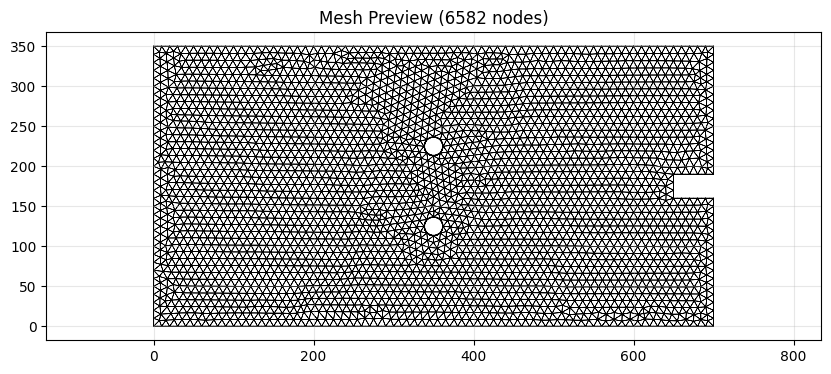

In [62]:
if mesh is not None:
    points = mesh.points
    triangles = mesh.cells_dict["triangle"]

    plt.figure(figsize=(10, 4))
    plt.triplot(points[:, 0], points[:, 1], triangles, lw=0.5, color='k')
    plt.title(f"Mesh Preview ({len(points)} nodes)")
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("⚠️ No mesh to preview.")

In [66]:
import plotly.graph_objects as go
import numpy as np

# 頂点座標の取得
points = mesh.points
x, y, z = points[:, 0], points[:, 1], points[:, 2]

# 四面体要素(tetra)の取得
if 'tetra' in mesh.cells_dict:
    tetras = mesh.cells_dict['tetra']
else:
    for block in mesh.cells:
        if block.type == 'tetra':
            tetras = block.data
            break

# 四面体の各面（三角形）を抽出
faces = []
for tet in tetras:
    # 四面体の4面を三角形として追加
    faces.append([tet[0], tet[1], tet[2]])
    faces.append([tet[0], tet[1], tet[3]])
    faces.append([tet[0], tet[2], tet[3]])
    faces.append([tet[1], tet[2], tet[3]])
faces = np.array(faces)

# Mesh3dで三角形面を描画
fig = go.Figure(data=[
    go.Mesh3d(
        x=x,
        y=y,
        z=z,
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color='lightblue',
        opacity=0.5,
        flatshading=True,
        name='Tetrahedral Elements'
    )
])

fig.update_layout(
    scene=dict(
        aspectmode='data',
        camera=dict(
            projection=dict(type='orthographic')  # ★平行投射に設定
        )
    ),
    title="3D Mesh Visualization (Elements)"
)

fig.show()

In [64]:
# --- 5. 保存（形状データのみ） ---
if mesh is not None:
    nodes = mesh.points[:, :2]
    elements = mesh.cells_dict["triangle"]

    # 物理条件はここでは決めず、枠だけ作っておく
    input_data = {
        "nodes": nodes.tolist(),
        "elements": elements.tolist(),
        "material": {
            "E": 210000.0,
            "thickness": 10.0
        },
        "conditions": {
            # 🌟 ここでは空にしておく（Pre側で判定させる）
            "fixed_nodes_x": [],
            "load_nodes": [],
            "total_force": 1000.0
        }
    }

    with open(OUTPUT_FILE, 'w') as f:
        json.dump(input_data, f, indent=4)

    print(f"🎉 Saved '{OUTPUT_FILE}' (Geometry only)")
    print(f"   Nodes: {len(nodes)}, Elements: {len(elements)}")
    print("   👉 Open the 'Pre' notebook to set boundary conditions.")

else:
    print("⚠️ Save skipped.")

🎉 Saved 'input.json' (Geometry only)
   Nodes: 6582, Elements: 12896
   👉 Open the 'Pre' notebook to set boundary conditions.


In [65]:
# --- 6. メッシュのエクスポート (修正版) ---
GMSH_OUTPUT_FILE = 'model_mesh.msh'

if mesh is not None:
    try:
        import meshio

        # 2D解析に必要な 'triangle' 要素のみを抽出して新しいメッシュオブジェクトを作成
        # これにより、不要な点要素や線要素による dim_tags エラーを回避します
        cells = [("triangle", mesh.cells_dict["triangle"])]

        out_mesh = meshio.Mesh(
            points=mesh.points,
            cells=cells,
            # 必要に応じて cell_data も引き継げますが、まずは最小構成で
        )

        # GMSH 2.2 形式は互換性が非常に高く、多くのソフトで UNV 同様に扱えます
        out_mesh.write(GMSH_OUTPUT_FILE, file_format="gmsh22")

        print(f"🎉 Exported triangle mesh to '{GMSH_OUTPUT_FILE}' (GMSH 2.2 format)")

    except Exception as e:
        print(f"❌ Export failed: {e}")
else:
    print("⚠️ Export skipped.")

Warning: Appending zeros to replace the missing physical tag data.

Warning: Appending zeros to replace the missing geometrical tag data.

🎉 Exported triangle mesh to 'model_mesh.msh' (GMSH 2.2 format)
